In [5]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import scanpy as sc
from scipy.sparse import issparse

from model_engine import NormativeModelEngine
from rare_event_scorer import RareEventScorer

BASE_DIR   = Path('.').resolve()                         
DATA_DIR   = BASE_DIR.parent / 'OpenAccess_nfcore'
H5AD_PATH  = DATA_DIR / 'Merged_Processed_AnnData_with_Batch_Biases_QC_Status.h5ad'
ENGINE_DIR = BASE_DIR / 'engine_state'
RARE_REF   = BASE_DIR / 'CV_Results' / 'rare_event_ref.pkl'

print(f'BASE_DIR  : {BASE_DIR}')
print(f'H5AD_PATH : {H5AD_PATH}')
print(f'Exists    : {H5AD_PATH.exists()}')

PALETTE = {'NBI': '#E41A1C', 'ZINBI': '#377EB8', 'Logistic': '#4DAF4A',
           'Rare': '#984EA3'}
BIAS_COLUMNS = [
    'log(Total Reads)', 'Spliced Reads (%)',
    'gDNA Contamination (Intron/Exon)', 'rRNA Fraction',
    "RNA Degradation (3' Bias)", 'Platelet Score',
    'GC Bias', 'Gene Length Bias', 'NG80', '(NP80/NG80)',
]

BASE_DIR  : /project/cfRNA_NormativeModeling/Modeling
H5AD_PATH : /project/cfRNA_NormativeModeling/OpenAccess_nfcore/Merged_Processed_AnnData_with_Batch_Biases_QC_Status.h5ad
Exists    : True


In [6]:
print('Loading h5ad...')
adata = sc.read_h5ad(H5AD_PATH)
obs_mask = (
    (adata.obs['QC_Passed'] == True) &
    (adata.obs['Phenotype_Processed'].notna()) &
    (adata.obs['Phenotype_Processed'] != 'Unknown') &
    (adata.obs['broad_protocol_category'] != 'Exome-based (EB)')
)

var_mask = (adata.var['GeneType'] == 'protein_coding')
adata = adata[obs_mask, var_mask].copy()
is_hc  = (adata.obs['Phenotype_Processed'].astype(str) == 'Healthy Control').values
is_dis = ~is_hc

Y = adata.X.toarray() if issparse(adata.X) else np.asarray(adata.X)
Y = np.round(Y).astype(np.float32)

X_raw      = adata.obs[BIAS_COLUMNS].values.astype(np.float64)
sample_ids = adata.obs_names.tolist()
gene_names = adata.var_names.tolist()
phenotypes = adata.obs['Phenotype_Processed'].astype(str).values

dis_idx    = np.where(is_dis)[0]
dis_names  = [sample_ids[i] for i in dis_idx]
dis_pheno  = phenotypes[dis_idx]

print(f'HC: {is_hc.sum()}  Disease: {is_dis.sum()}')
print(pd.Series(dis_pheno).value_counts().to_string())

Loading h5ad...
HC: 693  Disease: 913
CDCS                  224
Tuberculosis          103
ME/CFS                 90
Pancreatitis           81
Pancreatic Cancer      74
Pre-eclampsia          62
Liver Cancer           48
Colorectal Cancer      41
Lung Cancer            33
Stomach Cancer         29
Esophagus Cancer       27
MM                     18
Other Cancer           18
HIV                    13
HIV + Tuberculosis     11
ICI-m                  11
ICI-treated Cancer     11
MGUS                    8
Pancreatic Cancer       6
Liver Cirrhosis         5


In [10]:
out_path = BASE_DIR / "CV_Results" / "disease_scores_flagged.parquet"
all_scores = pd.read_parquet(out_path)

In [11]:
gene_sample_counts = all_scores.groupby(['phenotype', 'gene'])['sample'].nunique().reset_index(name='sample_count')
phenotype_totals = all_scores.groupby('phenotype')['sample'].nunique()
gene_sample_counts['total_samples'] = gene_sample_counts['phenotype'].map(phenotype_totals)
gene_sample_counts['proportion'] = gene_sample_counts['sample_count'] / gene_sample_counts['total_samples']
top_n_genes = (gene_sample_counts.sort_values(['phenotype', 'proportion'], ascending=[True, False])
                                    .groupby('phenotype')
                                    .head(20)
                                    .reset_index(drop=True))
selected_genes = top_n_genes["gene"].unique().tolist()
n_per_pheno    = all_scores.groupby("phenotype")["sample"].nunique()
print(f"선택 유전자 수: {len(selected_genes)}  "
      f"(질환 수 {top_n_genes['phenotype'].nunique()} × top 20)")

선택 유전자 수: 366  (질환 수 20 × top 20)


In [9]:
# all_scores 로드 (배치 셀 미실행 시 parquet에서 복원)
if "all_scores" not in vars():
    all_scores = pd.read_parquet(BASE_DIR / "CV_Results" / "disease_scores_flagged.parquet")
    print(f"Loaded all_scores from parquet: {len(all_scores):,} rows")

THR = 3.0
print(f"Z-score threshold: |z| ≥ {THR}")
print(f"Total flagged (gene×sample) rows: {len(all_scores):,}\n")

n_total = pd.Series(dis_pheno).value_counts().rename("n_total")
pheno_agg = (
    all_scores.groupby("phenotype")
    .agg(
        n_flagged_samples = ("sample", "nunique"),
        n_unique_genes    = ("gene",   "nunique"),
        total_events      = ("gene",   "count"),
        mean_score        = ("score",  "mean"),
        max_score         = ("score",  "max"),
    )
    .join(n_total, how="left")
)
pheno_agg["flag_rate_%"]      = (pheno_agg["n_flagged_samples"] / pheno_agg["n_total"] * 100).round(1)
pheno_agg["genes_per_sample"] = (pheno_agg["total_events"] / pheno_agg["n_flagged_samples"]).round(1)

# branch breakdown (NBI / logistic / rare 이벤트 수)
branch_piv = (
    all_scores.groupby(["phenotype", "branch"])["gene"]
    .count()
    .unstack(fill_value=0)
    .rename(columns={"count": "n_nbi", "logistic": "n_logistic", "rare": "n_rare"})
)
for col in ["n_nbi", "n_logistic", "n_rare"]:
    if col not in branch_piv.columns:
        branch_piv[col] = 0
pheno_agg = pheno_agg.join(branch_piv[["n_nbi", "n_logistic", "n_rare"]], how="left").fillna(0)

# 각 질환에서 가장 많은 샘플에서 flag된 유전자
top_gene = (
    all_scores.groupby(["phenotype", "gene"])["sample"]
    .nunique()
    .reset_index(name="cnt")
    .sort_values("cnt", ascending=False)
    .groupby("phenotype")
    .first()["gene"]
    .rename("top_gene")
)
pheno_agg = pheno_agg.join(top_gene, how="left")

pheno_summary = pheno_agg[[
    "n_total", "n_flagged_samples",
    "n_unique_genes", "genes_per_sample",
    "mean_score", "max_score",
    "n_nbi", "n_logistic", "n_rare",
    "top_gene",
]].sort_values("n_flagged_samples", ascending=False)

display(pheno_summary)

# ── 2. 샘플별 요약 ─────────────────────────────────────────────────
sample_agg = (
    all_scores.groupby(["sample", "phenotype"])
    .agg(
        n_flagged_genes = ("gene",  "nunique"),
        max_score       = ("score", "max"),
        mean_score      = ("score", "mean"),
    )
    .reset_index()
)

top_gene_per_sample = (
    all_scores.sort_values("score", ascending=False)
    .drop_duplicates("sample")
    .set_index("sample")["gene"]
    .rename("top_gene")
)
sample_summary = (
    sample_agg
    .join(top_gene_per_sample, on="sample")
    .sort_values("n_flagged_genes", ascending=False)
    .reset_index(drop=True)
)

display(sample_summary.head(30))
display(sample_summary.tail(30))
print(f"\n[전체 {len(sample_summary)} 샘플 flagged / {len(set(dis_pheno))} 질환]")

Z-score threshold: |z| ≥ 3.0
Total flagged (gene×sample) rows: 280,301



,n_total,n_flagged_samples,n_unique_genes,genes_per_sample,mean_score,max_score,n_nbi,n_logistic,n_rare,top_gene
phenotype,,,,,,,,,,
CDCS,224,224,13055,264.8,-1.038206,10.0,55307,3484,518,ENSG00000100380.16
Tuberculosis,103,103,10246,182.1,1.024445,10.0,17080,1468,211,ENSG00000154451.16
ME/CFS,90,90,6728,105.7,0.803716,10.0,8721,745,44,ENSG00000271723.5
Pancreatitis,81,81,10272,226.0,-0.882596,10.0,17402,788,118,ENSG00000197976.13
Pancreatic Cancer,74,74,9632,226.5,-0.762409,10.0,15874,778,110,ENSG00000163631.20
Pre-eclampsia,62,62,7138,176.2,-0.568810,10.0,10205,650,67,ENSG00000165246.16
Liver Cancer,48,48,12693,526.9,0.734019,10.0,23963,895,431,ENSG00000171564.13
Colorectal Cancer,41,41,9690,472.9,-1.488102,10.0,18809,502,76,ENSG00000197756.11
Lung Cancer,33,33,11922,800.6,-0.593125,10.0,25720,501,200,ENSG00000123268.10


,sample,phenotype,n_flagged_genes,max_score,mean_score,top_gene
0,SRR33475187,ICI-m,4246,10.000000,-0.726126,ENSG00000223569.8
1,SRR14506716,Lung Cancer,3252,10.000000,0.222641,ENSG00000189169.8
2,SRR14506765,Stomach Cancer,3163,5.612001,-3.637558,ENSG00000198586.15
3,SRR28476457,Tuberculosis,3070,10.000000,-1.025013,ENSG00000243501.5
4,SRR14506734,Liver Cancer,2905,10.000000,-1.971576,ENSG00000196711.9
5,SRR14506722,Lung Cancer,2676,10.000000,-0.239003,ENSG00000230045.4
6,SRR22507567,Liver Cancer,2656,10.000000,1.678126,ENSG00000177504.10
7,SRR22561273,Liver Cancer,2435,10.000000,4.151538,ENSG00000286920.2
8,SRR14506768,Stomach Cancer,2153,10.000000,-0.325958,ENSG00000226023.6
9,SRR15619070,MM,2103,10.000000,2.651417,ENSG00000270601.5


,sample,phenotype,n_flagged_genes,max_score,mean_score,top_gene
883,SRR29804058,Pancreatic Cancer,34,5.612001,1.375623,ENSG00000143473.15
884,SRR32981837,ME/CFS,33,5.092094,-0.085185,ENSG00000134265.14
885,SRR32981943,ME/CFS,32,5.612001,0.948620,ENSG00000203760.10
886,SRR29803937,Pancreatitis,32,5.612001,-0.251414,ENSG00000156219.19
887,SRR29804067,Pancreatitis,32,5.612001,1.272737,ENSG00000182156.11
888,SRR17333197,Pre-eclampsia,32,5.612001,0.121561,ENSG00000136436.17
889,SRR32981860,ME/CFS,32,4.137784,1.358056,ENSG00000254126.8
890,SRR28476492,Tuberculosis,31,4.504237,1.634667,ENSG00000156535.15
891,SRR32981855,ME/CFS,30,5.612001,2.081583,ENSG00000273802.3
892,SRR32981869,ME/CFS,30,5.612001,-0.309731,ENSG00000213190.5



[전체 913 샘플 flagged / 20 질환]


Selected genes in matrix: 366 / 366
pivot_z: (913, 366)  range [-5.6, 5.6]
Clustering 913 samples × 366 genes ...


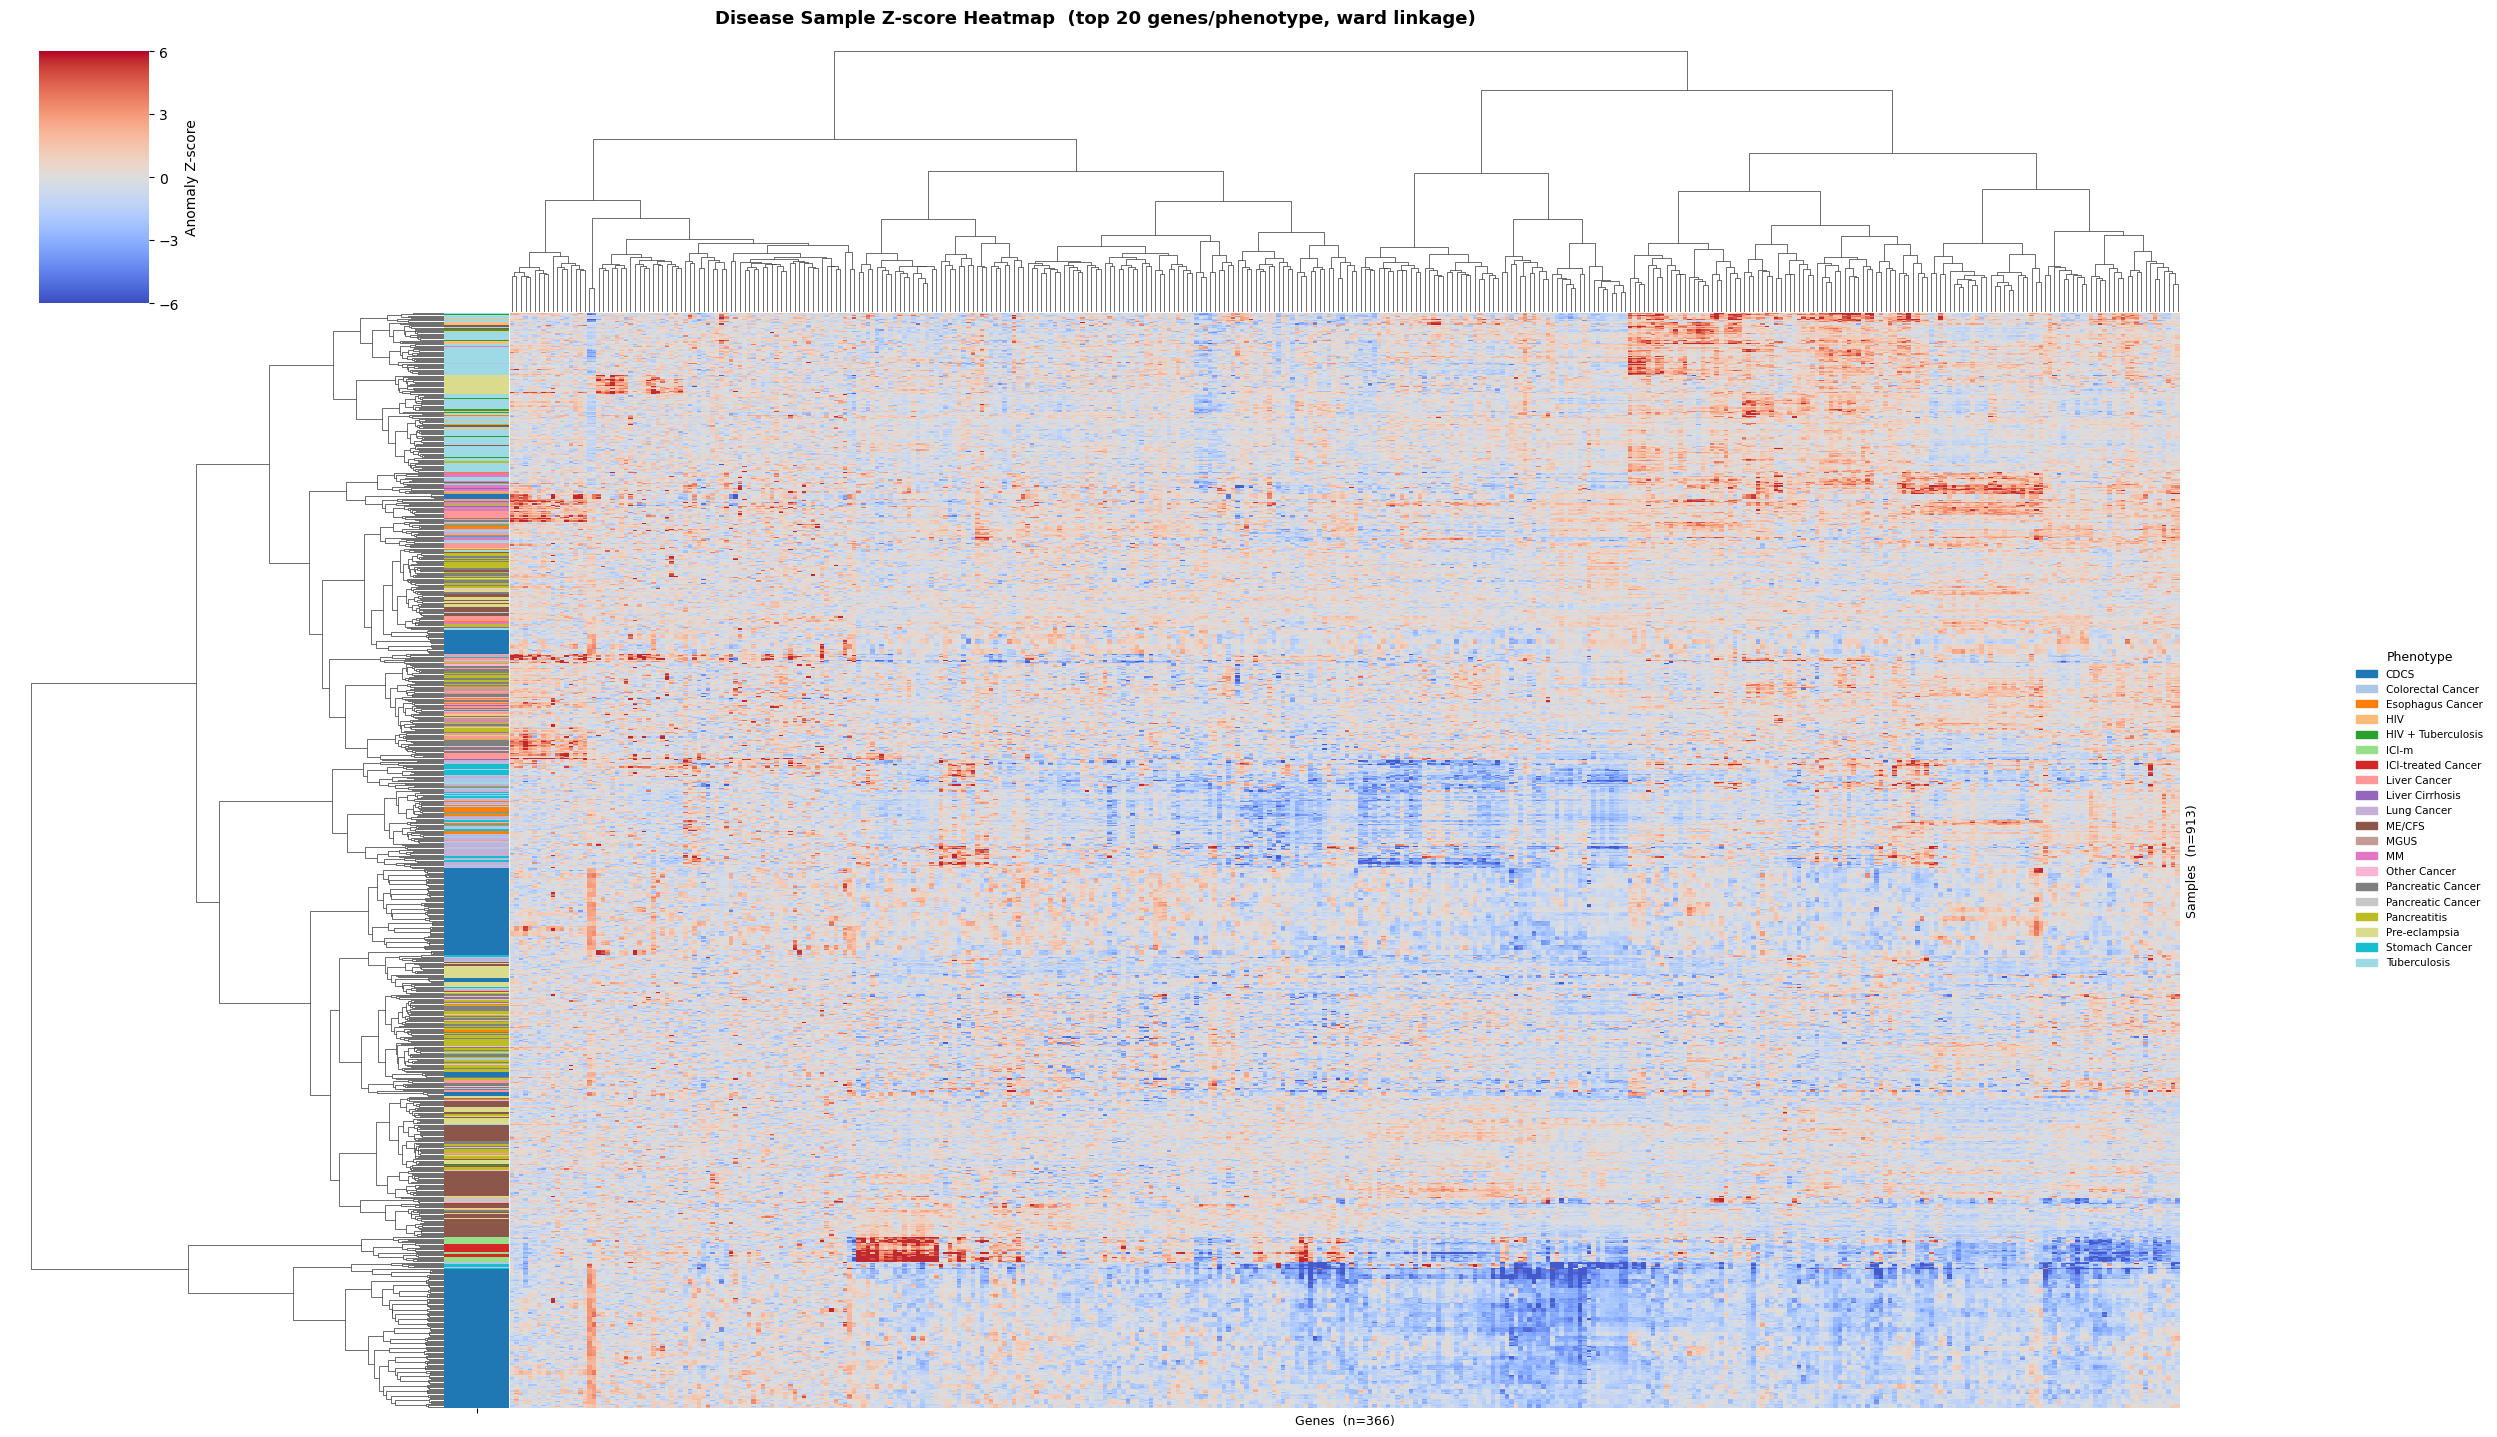

Saved → heatmap_disease_zscore.png


In [ ]:
import seaborn as sns
from matplotlib.patches import Patch

gn_map  = {g: i for i, g in enumerate(gene_names)}
sel_idx = [gn_map[g] for g in selected_genes if g in gn_map]
sel_ok  = [g for g in selected_genes if g in gn_map]
print(f"Selected genes in matrix: {len(sel_ok)} / {len(selected_genes)}")

if "Z_full" not in vars() or Z_full is None:
    print("Loading Z_full from disk...")
    Z_full      = np.load(BASE_DIR / "CV_Results" / "Z_disease.npy")
    dis_names_z = np.load(BASE_DIR / "CV_Results" / "Z_sample_names.npy", allow_pickle=True).tolist()
else:
    dis_names_z = list(dis_names)

pivot_z = pd.DataFrame(
    Z_full[:, sel_idx].astype(float),
    index   = dis_names_z,
    columns = sel_ok,
)
print(f"pivot_z: {pivot_z.shape}  "
      f"range [{pivot_z.values.min():.1f}, {pivot_z.values.max():.1f}]")

# ── 2. Phenotype → 색상 매핑 (tab20) ─────────────────────────────
unique_phenos = sorted(set(dis_pheno))
tab20_pal     = sns.color_palette("tab20", len(unique_phenos))
pheno_to_col  = dict(zip(unique_phenos, tab20_pal))
row_colors    = pd.Series(dis_pheno, index=dis_names_z).map(pheno_to_col)

# ── 3. Clustermap ─────────────────────────────────────────────────
VMAX = 6.0
print(f"Clustering {pivot_z.shape[0]} samples × {pivot_z.shape[1]} genes ...")
g = sns.clustermap(
    pivot_z,
    method      = "ward",
    metric      = "euclidean",
    row_colors  = row_colors,
    col_cluster = True,
    row_cluster = True,
    cmap        = "coolwarm",
    vmin        = -VMAX,
    vmax        =  VMAX,
    center      = 0,
    xticklabels = False,
    yticklabels = False,
    figsize     = (22, 14),
    cbar_kws    = dict(label="Anomaly Z-score", shrink=0.35,
                       ticks=[-6, -3, 0, 3, 6]),
    linewidths  = 0,
    rasterized  = True,
)

g.fig.suptitle(
    "Disease Sample Z-score Heatmap  (top 20 genes/phenotype, ward linkage)",
    y=1.01, fontsize=13, fontweight="bold",
)
g.ax_heatmap.set_xlabel(f"Genes  (n={len(sel_ok)})",      fontsize=9)
g.ax_heatmap.set_ylabel(f"Samples  (n={pivot_z.shape[0]})", fontsize=9)
 
# ── 4. Phenotype 범례 ─────────────────────────────────────────────
patches = [Patch(color=pheno_to_col[p], label=p) for p in unique_phenos]
g.ax_heatmap.legend(
    handles        = patches,
    loc            = "upper left",
    bbox_to_anchor = (1.1, 0.7),
    frameon        = False,
    fontsize       = 7.5,
    title          = "Phenotype",
    title_fontsize = 9,
    ncol           = 1,
)

out_path = BASE_DIR / "CV_Results" / "Figures" / "heatmap_disease_zscore.png"
plt.savefig(out_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {out_path.name}")


In [ ]:
from sklearn.metrics import silhouette_samples
from sklearn.neighbors import NearestNeighbors

# ── 0. 입력 행렬 (이전 셀에서 pivot_z 사용) ───────────────────────
X_mat  = pivot_z.values          # (913, 366)  float64
labels = np.array(dis_pheno)     # (913,)      str

# ── 1. Silhouette score (per sample → per phenotype mean) ─────────
print("Computing silhouette scores (euclidean) ...")
sil_vals = silhouette_samples(X_mat, labels, metric="euclidean")
sil_per  = (
    pd.DataFrame({"pheno": labels, "sil": sil_vals})
    .groupby("pheno")["sil"].mean()
    .sort_values(ascending=False)
)

# ── 2. kNN purity (k=15, exclude self) ───────────────────────────
K = 15
print(f"Computing kNN purity (k={K}) ...")
nbrs  = NearestNeighbors(n_neighbors=K + 1, metric="euclidean", n_jobs=-1).fit(X_mat)
_, nn = nbrs.kneighbors(X_mat)
nn    = nn[:, 1:]                # self 제외
purity = np.array([np.mean(labels[nn[i]] == labels[i]) for i in range(len(labels))])
pur_per = (
    pd.DataFrame({"pheno": labels, "pur": purity})
    .groupby("pheno")["pur"].mean()
)

# ── 3. 요약 테이블 ────────────────────────────────────────────────
n_per = pd.Series(labels).value_counts().rename("n")
summary = pd.DataFrame({
    "silhouette":  sil_per,
    "knn_purity":  pur_per,
    "n_samples":   n_per,
}).sort_values("silhouette", ascending=False)

print("\n── Clustering quality summary ──")
print(summary.round(3).to_string())


Computing silhouette scores (euclidean) ...
Computing kNN purity (k=15) ...

── Clustering quality summary ──
                    silhouette  knn_purity  n_samples
ICI-treated Cancer       0.206       0.515         11
Pancreatic Cancer        0.190       0.211          6
ME/CFS                   0.072       0.664         90
CDCS                     0.054       0.811        224
MGUS                     0.039       0.042          8
Tuberculosis             0.012       0.734        103
HIV + Tuberculosis      -0.017       0.103         11
Esophagus Cancer        -0.019       0.195         27
MM                      -0.027       0.152         18
ICI-m                   -0.030       0.370         11
Pancreatitis            -0.036       0.215         81
Pancreatic Cancer       -0.041       0.192         74
Other Cancer            -0.043       0.011         18
Pre-eclampsia           -0.046       0.248         62
Lung Cancer             -0.067       0.190         33
Colorectal Cancer       -0

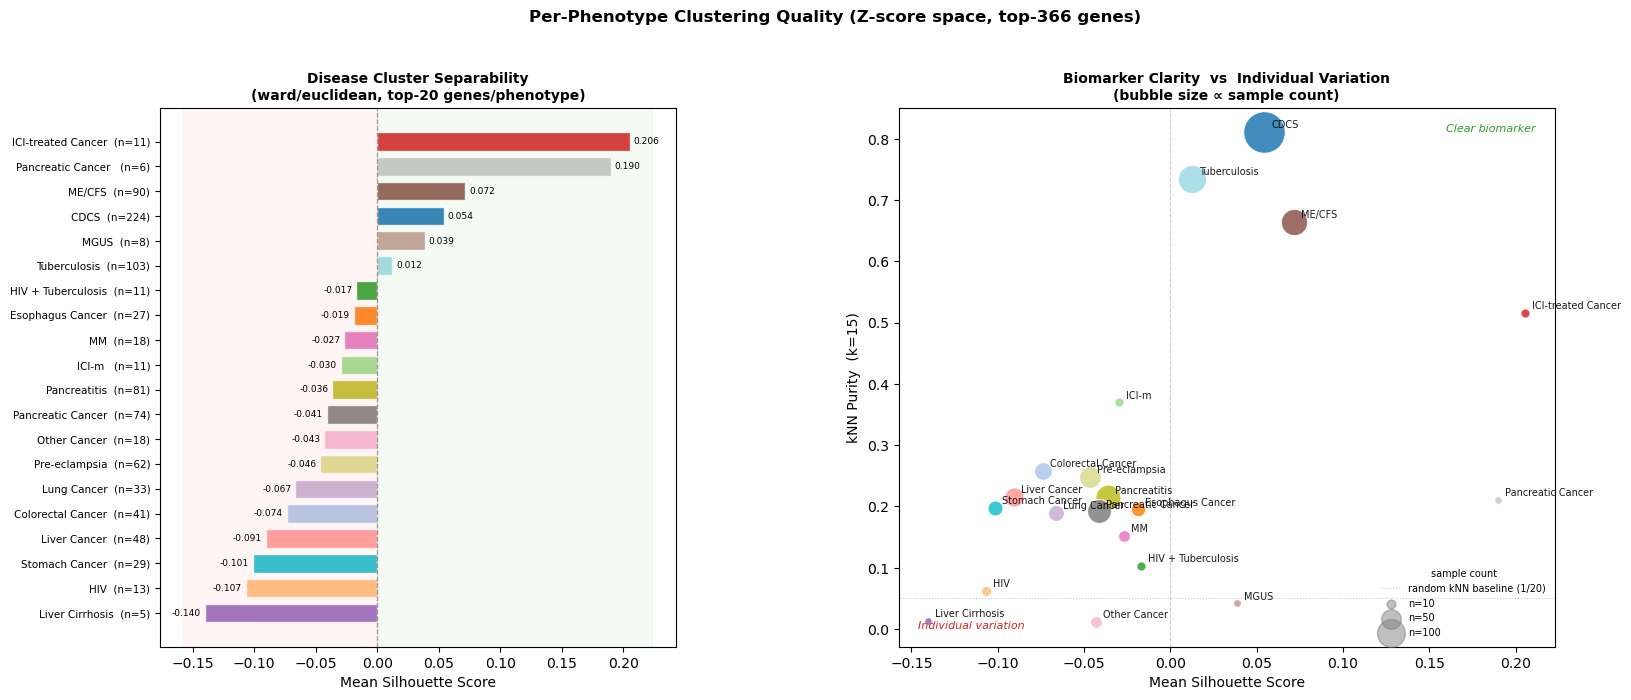

Saved → clustering_quality.png


In [ ]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(18, 7))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.1, 1.4], wspace=0.38)
ax_bar  = fig.add_subplot(gs[0])
ax_scat = fig.add_subplot(gs[1])

bar_colors = [pheno_to_col[p] for p in summary.index]
bars = ax_bar.barh(
    range(len(summary)), summary["silhouette"],
    color=bar_colors, alpha=0.88, edgecolor="white", height=0.75,
)
ax_bar.set_yticks(range(len(summary)))
ax_bar.set_yticklabels(
    [f"{p}  (n={int(summary.loc[p,'n_samples'])})" for p in summary.index],
    fontsize=7.5,
)
ax_bar.invert_yaxis()
ax_bar.axvline(0, color="black", lw=0.9, ls="--", alpha=0.35)
ax_bar.set_xlabel("Mean Silhouette Score", fontsize=10)
ax_bar.set_title(
    "Disease Cluster Separability\n(ward/euclidean, top-20 genes/phenotype)",
    fontsize=10, fontweight="bold",
)
for i, (p, row) in enumerate(summary.iterrows()):
    offset = 0.003 if row["silhouette"] >= 0 else -0.003
    ha     = "left"   if row["silhouette"] >= 0 else "right"
    ax_bar.text(row["silhouette"] + offset, i, f'{row["silhouette"]:.3f}',
                va="center", ha=ha, fontsize=6.5, color="black")

ax_bar.axvspan(ax_bar.get_xlim()[0], 0,   alpha=0.04, color="red")
ax_bar.axvspan(0, ax_bar.get_xlim()[1],    alpha=0.04, color="green")

for p, row in summary.iterrows():
    sz = max(row["n_samples"] * 4, 30)
    ax_scat.scatter(
        row["silhouette"], row["knn_purity"],
        color=pheno_to_col[p], s=sz,
        alpha=0.85, edgecolors="white", linewidth=0.8, zorder=3,
    )
    ax_scat.annotate(
        p, (row["silhouette"], row["knn_purity"]),
        xytext=(5, 3), textcoords="offset points",
        fontsize=7, alpha=0.9,
    )

ax_scat.axvline(0,   color="grey", lw=0.8, ls="--", alpha=0.4)
ax_scat.axhline(1/len(summary),  # random baseline for kNN purity
                color="grey", lw=0.8, ls=":", alpha=0.4,
                label=f"random kNN baseline (1/{len(summary)})")
ax_scat.set_xlabel("Mean Silhouette Score",   fontsize=10)
ax_scat.set_ylabel(f"kNN Purity  (k={K})",   fontsize=10)
ax_scat.set_title(
    "Biomarker Clarity  vs  Individual Variation\n(bubble size ∝ sample count)",
    fontsize=10, fontweight="bold",
)

ax_scat.text(0.97, 0.97, "Clear biomarker",
             transform=ax_scat.transAxes, ha="right", va="top",
             fontsize=8, color="#2ca02c", fontstyle="italic")
ax_scat.text(0.03, 0.03, "Individual variation",
             transform=ax_scat.transAxes, ha="left", va="bottom",
             fontsize=8, color="#d62728", fontstyle="italic")

for n_ex in [10, 50, 100]:
    ax_scat.scatter([], [], s=n_ex*4, color="grey", alpha=0.5, label=f"n={n_ex}")
ax_scat.legend(fontsize=7, frameon=False, loc="lower right", title="sample count", title_fontsize=7)

plt.suptitle(
    "Per-Phenotype Clustering Quality (Z-score space, top-366 genes)",
    fontsize=12, fontweight="bold", y=1.02,
)
out_path = BASE_DIR / "CV_Results" / "Figures" / "clustering_quality.png"
plt.savefig(out_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {out_path.name}")
